In [1]:
import sys
sys.path.append("..")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from torchsummary import summary

from utils.train_model import train_model


cudnn.benchmark = True
plt.ion()   # interactive mode

In [2]:
def summarize_diagnostics(history):
    """
    Функция для отрисовки значений LOSS и ACCURACY на каждой эпохе
    """
    fig,ax=plt.subplots(2)
    fig.suptitle("Loss")
    fig.tight_layout()
    # plot loss
    ax[0].set_title('Log Loss')
    ax[0].plot(history['train_loss'], color='blue', label='Training loss')
    ax[0].plot(history['test_loss'], color='orange', label='validation loss')
    ax[0].legend(loc='best', shadow=True)
    # plot accuracy
    ax[1].set_title('Classification Accuracy')
    ax[1].plot(history['train_acc'], color='blue', label='train')
    ax[1].plot(history['test_acc'], color='orange', label='test')
    ax[1].legend(loc='best', shadow=True)

In [3]:
def imshow(inp, title=None):
    """Отображаем батч картинок. Лучше всего печатать по 8 картинок. Так нагляднее."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

In [4]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [5]:
data_dir = "../data/cifake-real-and-ai-generated-synthetic-images"
image_datasets_logreg = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                                 data_transforms[x]
                                                 ) for x in ['train', 'test']}
# В документации написано, что если юзаешь CUDA, то необходимо выставлять pin_memory=True. Якобы так быстрее.
# https://pytorch.org/docs/stable/data.html
dataloaders_logreg = {x: torch.utils.data.DataLoader(image_datasets_logreg[x], 
													 batch_size=512,
													 shuffle=True, 
													 num_workers=0, 
													 pin_memory=True)
                for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets_logreg[x]) for x in ['train', 'test']}
class_names = image_datasets_logreg['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device!")

Using cuda:0 device!


In [6]:
# Я вставил это сюда, потому что у меня долгое время не использовался GPU при доступной CUDA. Искал решение. 

# https://pytorch.org/docs/stable/notes/cuda.html
# The flag below controls whether to allow TF32 on matmul. This flag defaults to False
# in PyTorch 1.12 and later.
#torch.backends.cuda.matmul.allow_tf32 = True

# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
#torch.backends.cudnn.allow_tf32 = True

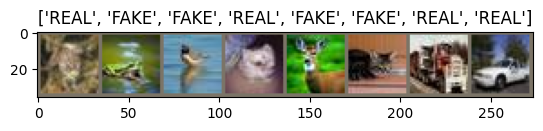

In [7]:
# отдельный DATALOADER для отрисовки, чтобы было удобнее
dataloaders_show = {x: torch.utils.data.DataLoader(image_datasets_logreg[x], batch_size=8,
                                                   shuffle=True, num_workers=0, pin_memory=True)
                                                   for x in ['train', 'test']}

# Get a batch of training data
inputs, classes = next(iter(dataloaders_show['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

[Отличное объяснение того, в чем разница между transfer_learning и fine_tuning](https://cs231n.github.io/transfer-learning/).

# ResNet18 (Feature Extractor) + LogReg

In [8]:
model_logreg = models.resnet18(weights='IMAGENET1K_V1')
# Фиксируем все параметры нейронной сети. Будем настраивать параметры только в fc-слое
for param in model_logreg.parameters():
    param.requires_grad = False

num_ftrs = model_logreg.fc.in_features
# Признаки, извлеченные из сверточных слоев пускаем на вход линейной модели
# nn.Sequential(nn.Linear(num_ftrs, 1), nn.Sigmoid()) - это равносильно sigmoid(x), где x - линейная комбинация признаков
# На выходе мы получаем вероятность принадлежности объекта к классу REAL (поскольку LABEL(REAL) == 1)
model_logreg.fc = nn.Sequential(nn.Linear(num_ftrs, 1), nn.Sigmoid())
model_logreg = model_logreg.cuda()

# BCELoss - это обычный logloss. CrossEntropy для логистической регрессии использовать некорректно
criterion_logreg = torch.nn.BCELoss()

# Меняем параметры только для fc-слоя
optimizer_logreg = optim.SGD(model_logreg.fc.parameters(), lr=0.01, momentum=0.9, weight_decay=0.01)

# Итеративное изменение градиентного шага. Прикольная вещь. Чем дольше мы обучаемся, тем по идее мы должны быть ближе к минимуму.
# А чем ближе к минимуму, тем меньший размер шагов мы должны делать, чтобы его случайно не перескочить и сойтись в нем.
# Итеративное изменения шага помогает это сделать
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_logreg, step_size=7, gamma=0.1)

In [9]:
# Обучаем модель
model_inf_logreg, dict_stat = train_model(model=model_logreg, 
                                          criterion=criterion_logreg, 
                                          optimizer=optimizer_logreg, 
                                          scheduler=exp_lr_scheduler, 
                                          dataset_sizes=dataset_sizes,
                                          dataloaders=dataloaders_logreg, 
                                          num_epochs=5,
                                          isLogreg=True,
                                          isSVM=False)

Epoch 0/4
----------
train Loss: 0.5137 Acc: 0.7376
test Loss: 0.4943 Acc: 0.7638

Epoch 1/4
----------
train Loss: 0.4929 Acc: 0.7568
test Loss: 0.4941 Acc: 0.7706

Epoch 2/4
----------
train Loss: 0.4903 Acc: 0.7585
test Loss: 0.4869 Acc: 0.7655

Epoch 3/4
----------
train Loss: 0.4919 Acc: 0.7578
test Loss: 0.4901 Acc: 0.7654

Epoch 4/4
----------
train Loss: 0.4914 Acc: 0.7567
test Loss: 0.4885 Acc: 0.7555

Training complete in 20m 28s
Best val Acc: 0.770550


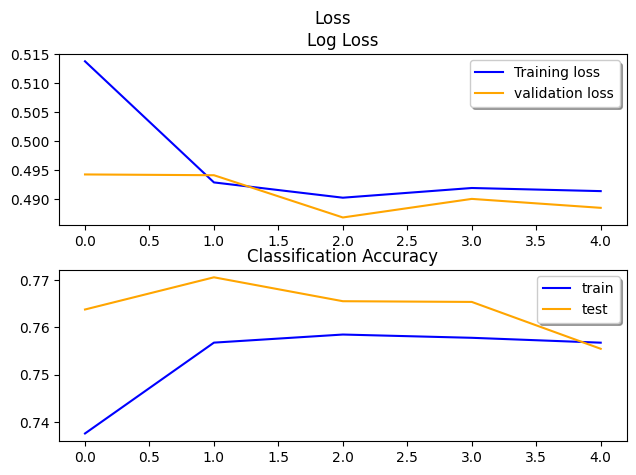

In [10]:
summarize_diagnostics(dict_stat)

Полный список претрейн моделей, доступных для трансфера из PyTorch: https://pytorch.org/vision/main/models.html

# ResNet18 (Feature Extractor) + SVM
Для реализации SVM мы воспользуемся Hinge Loss в качестве функции потерь.

Также необходимо перемэппить target из {0, 1} в {-1, 1} для корректной работы Hinge Loss.

In [12]:
class TargetMapper:
    def __init__(self, labels):
        self.labels_dict = {v: -1 if v=='REAL' else 1 for k, v in enumerate(labels)}
        self.labels_list = sorted(labels)

    def __call__(self, target):
        return self.labels_dict[self.labels_list[target]]

In [13]:
image_datasets_svm = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                              data_transforms[x],
                                              target_transform=TargetMapper(["REAL", "FAKE"]) # Трансформируем значения меток классов для SVM
                                              ) for x in ['train', 'test']}
# В документации написано, что если юзаешь CUDA, то необходимо выставлять pin_memory=True. Якобы так быстрее.
# https://pytorch.org/docs/stable/data.html
dataloaders_svm = {x: torch.utils.data.DataLoader(image_datasets_svm[x], batch_size=512,
                                                  shuffle=True, num_workers=0, pin_memory=True)
                for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets_svm[x]) for x in ['train', 'test']}
class_names = image_datasets_svm['train'].classes

In [14]:
model_svm = models.resnet18(weights='IMAGENET1K_V1')
# Фиксируем все параметры нейронной сети. Будем настраивать параметры только в fc-слое
for param in model_svm.parameters():
    param.requires_grad = False

num_ftrs = model_svm.fc.in_features
# Признаки, извлеченные из сверточных слоев пускаем на вход линейной модели
model_svm.fc = nn.Sequential(nn.Linear(num_ftrs, 1))
model_svm = model_svm.cuda()

# HingeEmbeddingLoss - это LOSS используемый для SVM
criterion_svm = torch.nn.HingeEmbeddingLoss()

# Меняем параметры только для fc-слоя
optimizer_svm = optim.SGD(model_svm.fc.parameters(), lr=0.01, momentum=0.7, weight_decay=0.01)

# Итеративное изменение градиентного шага. Прикольная вещь. Чем дольше мы обучаемся, тем по идее мы должны быть ближе к минимуму.
# А чем ближе к минимуму, тем меньший размер шагов мы должны делать, чтобы его случайно не перескочить и сойтись в нем.
# Итеративное изменения шага помогает это сделать
exp_lr_scheduler_svm = lr_scheduler.StepLR(optimizer_svm, step_size=7, gamma=0.1)

In [18]:
# Обучаем модель
model_inf_svm, dict_stat_svm = train_model(model_svm, 
                                           criterion_svm, 
                                           optimizer_svm, 
                                           exp_lr_scheduler_svm, 
										   dataset_sizes=dataset_sizes,
                                           dataloaders=dataloaders_svm, 
                                           num_epochs=5,
										   isLogreg=False,
                                           isSVM=True)

Epoch 0/4
----------
train Loss: 0.6050 Acc: 0.3698
test Loss: 0.6276 Acc: 0.4455

Epoch 1/4
----------
train Loss: 0.5592 Acc: 0.3801
test Loss: 0.5689 Acc: 0.4175

Epoch 2/4
----------
train Loss: 0.5561 Acc: 0.3818
test Loss: 0.5597 Acc: 0.3478

Epoch 3/4
----------
train Loss: 0.5556 Acc: 0.3800
test Loss: 0.5639 Acc: 0.4142

Epoch 4/4
----------
train Loss: 0.5536 Acc: 0.3806
test Loss: 0.5552 Acc: 0.3624

Training complete in 19m 29s
Best val Acc: 0.445500


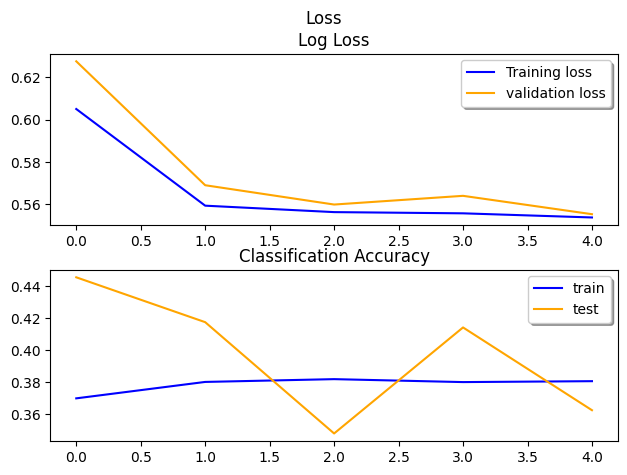

In [19]:
summarize_diagnostics(dict_stat_svm)

In [17]:
# # Способ вывести все имеющиеся у объекта методы: 
# # https://stackoverflow.com/questions/34439/finding-what-methods-a-python-object-has
# resnet18 = models.resnet18(weights='IMAGENET1K_V1')

# object_methods = [method_name for method_name in dir(resnet18)
#                   if callable(getattr(resnet18, method_name))]

# object_methods

Тест GPU

In [ ]:
ac = torch.randn(10000, 10000).to(device)
bc = torch.randn(10000, 10000).to(device)
%time cc = torch.matmul(ac, bc)

CPU times: user 112 μs, sys: 13 μs, total: 125 μs
Wall time: 129 μs


In [ ]:
ac = torch.randn(10000, 10000)#.to(device)
bc = torch.randn(10000, 10000)#.to(device)
%time cc = torch.matmul(ac, bc)

CPU times: user 24.1 s, sys: 154 ms, total: 24.3 s
Wall time: 4.32 s


In [ ]:
#!nvidia-smi